# Linear Learner Binary Classification Demo

This notebook demonstrates how to train and deploy an AWS SageMaker **Linear Learner** model for a **binary classification** task.

### What You Need
- A preprocessed CSV file produced by the DATA/LINEAR_LEARNER preprocessing lab
- The CSV should have **no header row**, with the **target variable in the first column** and all features in the remaining columns
- All values should be numeric (categorical features already encoded)

### What This Notebook Does
1. Loads your preprocessed dataset
2. Creates a binary target variable (above/below median)
3. Splits data into training and validation sets
4. Uploads data to S3
5. Trains a Linear Learner binary classification model on SageMaker
6. Deploys the model to a real-time endpoint
7. Evaluates model performance (Accuracy, Precision, Recall, F1)
8. Lets you interactively query the model
9. Cleans up AWS resources

# STEP 1: IMPORT LIBRARIES AND SETUP

In [ ]:
# Install any packages not included in the SageMaker environment
!pip install seaborn -q

In [1]:
# Standard Libraries
import os
import time
import logging

# Data Handling & Visualization Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn Libraries for Model Building & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

# AWS & SageMaker Libraries for Model Training and Deployment
import boto3
import sagemaker
from sagemaker import Session, get_execution_role
from sagemaker.estimator import Estimator
from sagemaker.amazon.linear_learner import LinearLearner  # SageMaker's built-in Linear Learner algorithm
from sagemaker.inputs import TrainingInput
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

# Additional Libraries
from botocore.exceptions import ClientError
from typing import Any, List, Union

# Logger Setup
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ============================================================
# CONFIGURATION - Update these values for your dataset
# ============================================================
file_path = "ames_housing_preprocessed.csv"   # Path to your preprocessed CSV file
target_name = "SalePrice"                      # For display only (plot labels, print statements) -- not in the CSV
endpoint_name = "binary-learner-endpoint"      # Name for the SageMaker endpoint


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[02/03/25 11:54:37] INFO     Found credentials from IAM Role:                                   ]8;id=172184;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=463085;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


# STEP 2: LOAD PREPROCESSED DATA

This notebook uses a preprocessed dataset produced by the DATA/LINEAR_LEARNER lab.
That lab handles all data cleaning, missing value imputation, outlier removal,
and categorical encoding.

**Before running this notebook**, copy your preprocessed CSV file into this
notebook's directory and update the `file_path` and `target_name` variables in Step 1.

In [ ]:
def load_preprocessed_data(filepath):
    """
    Load the preprocessed Ames Housing dataset.

    This file was produced by the DATA/LINEAR_LEARNER preprocessing lab
    and contains all features already cleaned and encoded.
    Format: No header row, SalePrice in the first column (SageMaker CSV format).
    """
    df = pd.read_csv(filepath, header=None)

    # Name the first column (target) so we can reference it by name
    df.rename(columns={0: target_name}, inplace=True)

    print(f"Loaded preprocessed data: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"First column: {df.columns[0]} (target variable)")
    print(f"\nFirst 5 rows:")
    display(df.head())
    return df

df = load_preprocessed_data(file_path)

# STEP 3: CREATE A BINARY TARGET

In [8]:
# Calculate the median of the target variable.
# This median value acts as a threshold to classify observations.
median_value = df[target_name].median()

# Create a new binary column 'BinaryTarget' based on the median:
#   - 1 if the target value is above the median.
#   - 0 if the target value is at or below the median.
df["BinaryTarget"] = (df[target_name] > median_value).astype(int)

# Remove the original target column to simplify the dataset for classification.
df.drop(columns=[target_name], inplace=True)

# Update the target column reference for further processing.
target_col = "BinaryTarget"

# Define display labels for the binary classes
label_map = {0: f"Below Median {target_name}", 1: f"Above Median {target_name}"}

# Print the distribution of the new binary target classes
class_counts = df[target_col].value_counts().sort_index()
class_percentages = (class_counts / len(df)) * 100

print(f"\nMedian {target_name}: {median_value:,.2f}")
print(f"\nTarget Distribution:")
for category, count in class_counts.items():
    print(f"  {label_map[category]}: {count} samples ({class_percentages[category]:.2f}%)")

# Print a sample of the modified DataFrame
print("\nSample of the Modified Dataset:")
print(df.head())


Target Distribution:
Class 0: 1466 samples (50.12%)
Class 1: 1459 samples (49.88%)

Sample of the Modified Dataset:
   Order        PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
0      1  526301100           20         141.0     31770             6   
1      2  526350040           20          80.0     11622             5   
2      3  526351010           20          81.0     14267             6   
3      4  526353030           20          93.0     11160             7   
4      5  527105010           60          74.0     13830             5   

   Overall Cond  Year Built  Year Remod/Add  Mas Vnr Area  ...  Sale Type_New  \
0             5        1960            1960         112.0  ...              0   
1             6        1961            1961           0.0  ...              0   
2             6        1958            1958         108.0  ...              0   
3             5        1968            1968           0.0  ...              0   
4             5        1997      

# STEP 4: SPLIT THE DATA INTO TRAIN AND VALIDATION

In [9]:
# Separate the features (X) and the target variable (y).
# X contains all columns except the target column.
# y contains only the target column.
X = df.drop(columns=[target_col])  # Features (predictor variables)
y = df[target_col]  # Target variable

# Split the data into training and validation sets.
# 'test_size=0.2' means 20% of the data is reserved for validation, and 80% for training.
# 'random_state=42' ensures that the split remains the same each time the code is run.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and validation sets to confirm successful splitting.
print(f"Training set: Features {X_train.shape}, Target {y_train.shape}")
print(f"Validation set: Features {X_val.shape}, Target {y_val.shape}")


Training set: Features (2340, 203), Target (2340,)
Validation set: Features (585, 203), Target (585,)


# STEP 5: PREPARE FILES AND SET UP SAGEMAKER SESSION

In [10]:
# Initialize a SageMaker session
sagemaker_session = sagemaker.Session()

# Get IAM role associated with SageMaker
role = get_execution_role()

# Define S3 bucket, AWS region, and S3 folder prefix for storing data
bucket = sagemaker_session.default_bucket()  # Default S3 bucket assigned by SageMaker
region = sagemaker_session.boto_region_name  # AWS region of the session
prefix = "sagemaker/binary-ames-housing"  # Folder path in S3

# Combine target labels (y) and feature data (X) for training and validation sets
train_data = pd.concat([y_train, X_train], axis=1)
validation_data = pd.concat([y_val, X_val], axis=1)

# Check for missing values and print a warning if found
if train_data.isnull().values.any() or validation_data.isnull().values.any():
    print("Warning: Missing values detected! Consider handling them before training.")

# Check for class imbalance and print a warning if any class dominates (>75% of the data)
train_class_distribution = y_train.value_counts(normalize=True)
val_class_distribution = y_val.value_counts(normalize=True)

if train_class_distribution.max() > 0.75 or val_class_distribution.max() > 0.75:
    print("Warning: Class imbalance detected. Consider balancing the dataset.")

# Define filenames for local storage
train_file = "ames_binary_train.csv"
validation_file = "ames_binary_validation.csv"

# Save training and validation data to CSV files (no headers, no index)
train_data.to_csv(train_file, index=False, header=False)
validation_data.to_csv(validation_file, index=False, header=False)

# Upload datasets to Amazon S3 and retrieve their S3 locations
train_uri = sagemaker_session.upload_data(path=train_file, bucket=bucket, key_prefix=prefix)
validation_uri = sagemaker_session.upload_data(path=validation_file, bucket=bucket, key_prefix=prefix)

# Print the S3 paths of uploaded datasets for reference
print(f"Training data uploaded to: {train_uri}")
print(f"Validation data uploaded to: {validation_uri}")


[02/03/25 11:54:39] INFO     Found credentials from IAM Role:                                   ]8;id=19748;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=910917;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Found credentials from IAM Role:                                   ]8;id=744641;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=291061;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

Training data uploaded to: s3://sagemaker-us-east-1-785881939712/sagemaker/binary-ames-housing/ames_binary_train.csv
Validation data uploaded to: s3://sagemaker-us-east-1-785881939712/sagemaker/binary-ames-housing/ames_binary_validation.csv


# STEP 6: TRAIN THE LINEAR LEARNER MODEL (BINARY CLASSIFICATION)

In [11]:
"""
This script sets up and launches an AWS SageMaker training job using the Linear Learner algorithm for binary classification.
It retrieves the container image URI, configures the estimator with the required hyperparameters, prepares the training and validation data from S3,
and then initiates the training job.
"""

# Retrieve the container URI for the Linear Learner model.
# This container includes the runtime needed to train the model.
container = sagemaker.image_uris.retrieve(
    framework="linear-learner",
    region=region  # AWS region, e.g., 'us-west-2'
)

# Instantiate the SageMaker Estimator for the Linear Learner model.
# The Estimator configures the container, IAM role, compute resources, and the S3 location where the model outputs will be stored.
linear_learner = Estimator(
    image_uri=container,                        # The container image for Linear Learner.
    role=role,                                  # The IAM role granting SageMaker necessary resource permissions.
    instance_count=1,                           # Number of instances to use for training.
    instance_type='ml.m5.large',                # Chosen instance type based on resource requirements.
    output_path=f's3://{bucket}/{prefix}/output',# S3 bucket and prefix for storing model artifacts.
    sagemaker_session=sagemaker_session         # The active SageMaker session.
)

# Determine the number of features in the dataset.
# This value is used to set the 'feature_dim' hyperparameter, which tells the model how many input features there are.
num_features = X.shape[1]

# Set hyperparameters for the binary classification task.
# - feature_dim: Number of input features.
# - predictor_type: 'binary_classifier' specifies that this is a binary classification problem.
# - mini_batch_size: Number of samples per mini-batch during training.
linear_learner.set_hyperparameters(
    feature_dim=num_features,
    predictor_type='binary_classifier',
    mini_batch_size=32,
)

# Prepare the training and validation datasets for SageMaker.
# The TrainingInput object specifies the S3 URI of the data and its format (CSV in this case).
train_input = TrainingInput(s3_data=train_uri, content_type="text/csv")
validation_input = TrainingInput(s3_data=validation_uri, content_type="text/csv")

# Launch the training job.
# The fit method starts the training process on SageMaker using the provided training and validation data.
linear_learner.fit({'train': train_input, 'validation': validation_input})

# Notify the user that model training is complete.
print("Model training complete!")


[02/03/25 11:54:40] INFO     Same images used for training and inference. Defaulting to image     ]8;id=787808;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=498261;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#391\391]8;;\
                             scope: inference.                                                                     

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=873413;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=242545;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#528\528]8;;\

                    INFO     Found credentials from IAM Role:                                   ]8;id=656941;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=296597;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

[02/03/25 11:54:41] INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=383857;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=580496;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name:                                       ]8;id=471601;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=177145;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\
                             linear-learner-2025-02-03-11-54-41-094                                                

2025-02-03 11:54:44 Starting - Starting the training job...
..25-02-03 11:54:57 Starting - Preparing the instances for training.
..25-02-03 11:55:25 Downloading - Downloading input data.
.....02-03 11:56:05 Downloading - Downloading the training image.
.Docker entrypoint called with argument(s): trainpleted. Training in progress..
Running default environment configuration script
[02/03/2025 11:57:20 INFO 140680206198592] Reading default configuration from /opt/amazon/lib/python3.8/site-packages/algorithm/resources/default-input.json: {'mini_batch_size': '1000', 'epochs': '15', 'feature_dim': 'auto', 'use_bias': 'true', 'binary_classifier_model_selection_criteria': 'accuracy', 'f_beta': '1.0', 'target_recall': '0.8', 'target_precision': '0.8', 'num_models': 'auto', 'num_calibration_samples': '10000000', 'init_method': 'uniform', 'init_scale': '0.07', 'init_sigma': '0.01', 'init_bias': '0.0', 'optimizer': 'auto', 'loss': 'auto', 'margin': '1.0', 'quantile': '0.5', 'loss_insensitivity': '

# STEP 7: DEPLOY THE MODEL

In [12]:
sm_client = boto3.client("sagemaker")

# -----------------------------------------------------------------------------
# 1. Use built-in waiter for InService (optional, but handy for waiting on creation)
# -----------------------------------------------------------------------------
endpoint_in_service_waiter = sm_client.get_waiter('endpoint_in_service')

def delete_endpoint_and_config(endpoint_name: str, wait_for_deletion: bool = True) -> None:
    """
    Deletes an endpoint and its corresponding endpoint configuration (if they exist).
    Optionally polls until resources are deleted.
    """
    # 1. Delete endpoint (if it exists).
    try:
        endpoint_desc = sm_client.describe_endpoint(EndpointName=endpoint_name)
        endpoint_status = endpoint_desc["EndpointStatus"]

        # If the endpoint is Creating or Updating, wait for it to become InService before deleting.
        if endpoint_status in ("Creating", "Updating"):
            logger.info(f"Endpoint '{endpoint_name}' is in '{endpoint_status}' state. Waiting before delete.")
            endpoint_in_service_waiter.wait(EndpointName=endpoint_name)  # Waits until 'InService'
        
        # Now delete
        logger.info(f"Deleting endpoint: {endpoint_name}")
        sm_client.delete_endpoint(EndpointName=endpoint_name)

    except ClientError as e:
        # If the endpoint was never found, ignore the error. Otherwise, re-raise.
        if e.response['Error']['Code'] == 'ValidationException' and "Could not find" in e.response['Error']['Message']:
            logger.info(f"Endpoint '{endpoint_name}' does not exist or has already been deleted.")
        else:
            raise e

    # 2. Delete endpoint config (if it exists).
    try:
        sm_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
        logger.info(f"Deleting endpoint configuration: {endpoint_name}")
        sm_client.delete_endpoint_config(EndpointConfigName=endpoint_name)
    except ClientError as e:
        if e.response['Error']['Code'] == 'ValidationException' and "Could not find" in e.response['Error']['Message']:
            logger.info(f"Endpoint config '{endpoint_name}' does not exist or has already been deleted.")
        else:
            raise e

    # 3. Optionally poll for deletion. (There's no built-in waiter for deletion.)
    #    Below is a simple polling strategy for demonstration.
    if wait_for_deletion:
        logger.info("Waiting for endpoint & configuration to be deleted...")
        for _ in range(30):
            endpoint_exists = True
            endpoint_config_exists = True

            # Check endpoint
            try:
                sm_client.describe_endpoint(EndpointName=endpoint_name)
            except ClientError as e:
                if "Could not find" in e.response["Error"]["Message"]:
                    endpoint_exists = False

            # Check endpoint config
            try:
                sm_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
            except ClientError as e:
                if "Could not find" in e.response["Error"]["Message"]:
                    endpoint_config_exists = False

            if not endpoint_exists and not endpoint_config_exists:
                logger.info("Endpoint and endpoint config fully deleted.")
                break

            logger.info("Endpoint or endpoint config still deleting... sleeping 10s.")
            time.sleep(10)
        else:
            logger.warning("Endpoint or endpoint config not fully deleted after 30 checks.")

def delete_model(model_name: str, wait_for_deletion: bool = True) -> None:
    """
    Deletes a SageMaker model if it exists. Optionally waits until it disappears.
    """
    try:
        sm_client.describe_model(ModelName=model_name)
        logger.info(f"Deleting model: {model_name}")
        sm_client.delete_model(ModelName=model_name)
    except ClientError as e:
        if "Could not find" in e.response["Error"]["Message"]:
            logger.info(f"Model '{model_name}' does not exist or is already deleted.")
        else:
            raise e

    if wait_for_deletion:
        # There's no official 'model deleted' waiter, so we poll:
        for _ in range(20):
            try:
                sm_client.describe_model(ModelName=model_name)
                logger.info("Model still deleting... sleeping 5s.")
                time.sleep(5)
            except ClientError as e:
                if "Could not find" in e.response["Error"]["Message"]:
                    logger.info("Model fully deleted.")
                    break
        else:
            logger.warning("Model was not deleted after waiting.")


delete_endpoint_and_config(endpoint_name)
# If your model is also named the same, you might do:
# delete_model(endpoint_name)

predictor = linear_learner.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    endpoint_name=endpoint_name
)

predictor.serializer = CSVSerializer()
predictor.deserializer = JSONDeserializer()

logger.info(f"Endpoint '{endpoint_name}' deployed successfully and ready for inference.")


[02/03/25 11:58:59] INFO     Deleting endpoint: binary-learner-endpoint                             ]8;id=859550;file:///tmp/ipykernel_28174/718170243.py\718170243.py]8;;\:]8;id=328082;file:///tmp/ipykernel_28174/718170243.py#26\26]8;;\

                    INFO     Deleting endpoint configuration: binary-learner-endpoint               ]8;id=586328;file:///tmp/ipykernel_28174/718170243.py\718170243.py]8;;\:]8;id=554525;file:///tmp/ipykernel_28174/718170243.py#39\39]8;;\

[02/03/25 11:59:00] INFO     Waiting for endpoint & configuration to be deleted...                  ]8;id=418718;file:///tmp/ipykernel_28174/718170243.py\718170243.py]8;;\:]8;id=146860;file:///tmp/ipykernel_28174/718170243.py#50\50]8;;\

                    INFO     Endpoint or endpoint config still deleting... sleeping 10s.            ]8;id=639348;file:///tmp/ipykernel_28174/718170243.py\718170243.py]8;;\:]8;id=614208;file:///tmp/ipykernel_28174/718170243.py#73\73]8;;\

[02/03/25 11:59:10] INFO     Endpoint and endpoint config fully deleted.                            ]8;id=413828;file:///tmp/ipykernel_28174/718170243.py\718170243.py]8;;\:]8;id=15561;file:///tmp/ipykernel_28174/718170243.py#70\70]8;;\

                    INFO     Creating model with name: linear-learner-2025-02-03-11-59-10-502       ]8;id=30931;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=102204;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4094\4094]8;;\

[02/03/25 11:59:11] INFO     Creating endpoint-config with name binary-learner-endpoint             ]8;id=227663;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=992746;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#5889\5889]8;;\

                    INFO     Creating endpoint with name binary-learner-endpoint                    ]8;id=117185;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=227370;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4711\4711]8;;\

-------!

[02/03/25 12:03:12] INFO     Endpoint 'binary-learner-endpoint' deployed successfully and ready    ]8;id=364072;file:///tmp/ipykernel_28174/718170243.py\718170243.py]8;;\:]8;id=3546;file:///tmp/ipykernel_28174/718170243.py#120\120]8;;\
                             for inference.                                                                        

# STEP 8: EVALUATE THE DEPLOYED MODEL


 **Evaluation Metrics:**
  Accuracy:  0.9368
  Precision: 0.9565
  Recall:    0.9135
  F1 Score:  0.9345

**Classification Report:**
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       296
           1       0.96      0.91      0.93       289

    accuracy                           0.94       585
   macro avg       0.94      0.94      0.94       585
weighted avg       0.94      0.94      0.94       585


**Confusion Matrix (Raw Values):**
[[284  12]
 [ 25 264]]


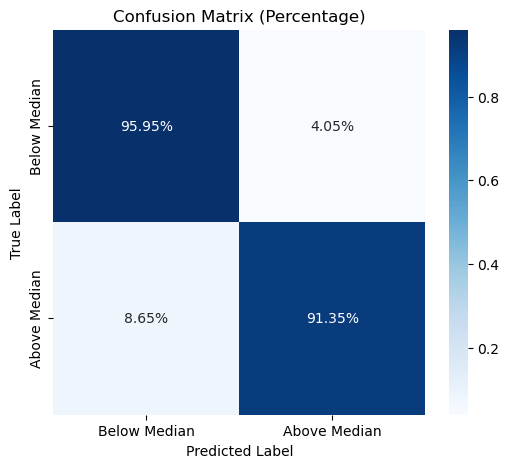

{'Accuracy': 0.9367521367521368, 'Precision': 0.9565217391304348, 'Recall': 0.9134948096885813, 'F1 Score': 0.9345132743362832}


In [13]:
def evaluate_deployed_classifier(predictor, X_val, y_val):
    """
    Evaluate the deployed classification model on the test set.

    Fixes:
      - Extracts only 'predicted_label'.
      - Limits printed output for readability.
      - Handles unexpected response formats safely.

    Parameters:
      predictor: SageMaker Predictor object for the deployed model.
      X_val (pd.DataFrame): Test features.
      y_val (pd.Series): True labels.

    Returns:
      dict: Evaluation metrics (Accuracy, Precision, Recall, F1 Score)
    """

    # Ensure the predictor uses the correct serialization
    predictor.serializer = CSVSerializer()

    # Copy test features and labels
    X_test = X_val.copy()
    y_test = y_val.copy()

    # Get predictions from the deployed endpoint
    predictions = predictor.predict(X_test.values.astype(np.float64))

    # Ensure correct extraction of predicted labels
    try:
        predicted_labels = [int(result["predicted_label"]) for result in predictions["predictions"]]
    except (KeyError, TypeError) as e:
        print(f"Error extracting predictions: {e}")
        return None  # Stop execution if predictions are not correctly formatted

    # Compute evaluation metrics
    acc = accuracy_score(y_test, predicted_labels)
    prec = precision_score(y_test, predicted_labels, zero_division=0)
    rec = recall_score(y_test, predicted_labels, zero_division=0)
    f1 = f1_score(y_test, predicted_labels, zero_division=0)

    # Print evaluation metrics
    print("\n **Evaluation Metrics:**")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}\n")

    # Print detailed classification report
    print("**Classification Report:**")
    print(classification_report(y_test, predicted_labels))

    # Compute and visualize the confusion matrix
    cm = confusion_matrix(y_test, predicted_labels)
    print("\n**Confusion Matrix (Raw Values):**")
    print(cm)

    # Confusion Matrix with percentages for better readability
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize per class
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_percent, annot=True, fmt=".2%", cmap="Blues",
                xticklabels=[label_map[0], label_map[1]],
                yticklabels=[label_map[0], label_map[1]])
    plt.title("Confusion Matrix (Percentage)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Return computed evaluation metrics
    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }

# Example call:
# Replace 'predictor', 'X_val', and 'y_val' with actual objects
metrics = evaluate_deployed_classifier(predictor, X_val, y_val)
print(metrics)


# STEP 9: QUERY THE DEPLOYED ENDPOINT WITH TEST DATA

In [ ]:
def query_test_predictions(predictor, X_val, y_val, n_samples=5):
    """
    Query the deployed endpoint with test data and display results as a
    formatted DataFrame table with probability bar chart and accuracy summary.

    Parameters:
        predictor: The SageMaker Predictor object.
        X_val (pd.DataFrame): Validation features.
        y_val (pd.Series): True target values.
        n_samples (int): Number of samples to query.
    """
    # Select the first n rows from the validation set
    sample_data = X_val.head(n_samples)
    input_data = sample_data.values.astype(np.float64)

    # Request predictions from the deployed endpoint
    predictions = predictor.predict(input_data)

    if "predictions" not in predictions:
        print("No 'predictions' key found in the response:", predictions)
        return

    # Extract probabilities and compute predicted classes
    probabilities = [float(result["score"]) for result in predictions["predictions"]]
    threshold = 0.5
    predicted_classes = [1 if p > threshold else 0 for p in probabilities]
    actual_classes = y_val.loc[sample_data.index].tolist()
    results = ["CORRECT" if p == a else "INCORRECT" for p, a in zip(predicted_classes, actual_classes)]

    # Build a results DataFrame
    results_df = pd.DataFrame({
        "Sample": [f"Row {i}" for i in range(1, n_samples + 1)],
        "Probability": [f"{p:.4f}" for p in probabilities],
        "Predicted": [f"{c} ({label_map[c]})" for c in predicted_classes],
        "Actual": [f"{a} ({label_map[a]})" for a in actual_classes],
        "Result": results
    })

    print("\nTest Predictions on 5 Validation Samples:")
    display(results_df)

    # Accuracy summary
    n_correct = results.count("CORRECT")
    print(f"\nAccuracy: {n_correct} of {n_samples} correct ({n_correct/n_samples*100:.0f}%)")

    # Horizontal bar chart showing prediction probabilities with threshold line
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#55A868" if r == "CORRECT" else "#C44E52" for r in results]
    y_pos = np.arange(n_samples)
    bars = ax.barh(y_pos, probabilities, color=colors, height=0.6)

    # Add threshold line at 0.5
    ax.axvline(x=threshold, color="black", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")

    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"Row {i}" for i in range(1, n_samples + 1)])
    ax.set_xlabel("Prediction Probability (Above Median)")
    ax.set_title("Prediction Probabilities with Classification Threshold")
    ax.set_xlim(0, 1)
    ax.legend()

    # Add predicted label text on each bar
    for i, (prob, pred_class) in enumerate(zip(probabilities, predicted_classes)):
        ax.text(prob + 0.02, i, f"{label_map[pred_class]}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

query_test_predictions(predictor, X_val, y_val)

# STEP 10: INTERACTIVE PREDICTION

Now it is your turn! Select any row from the validation set by entering its row number.
The model will predict whether the target value is above or below the median
and compare it to the actual classification.

Enter `quit` when you are done exploring.

In [ ]:
def interactive_prediction():
    """
    Allow students to select validation rows, predict binary class,
    and visualize the prediction probability relative to the threshold.
    """
    threshold = 0.5

    print(f"Validation set has {len(X_val)} rows (indices 0 to {len(X_val)-1})")
    print("Enter a row number to predict its class, or 'quit' to stop.\n")

    while True:
        user_input = input("Enter row number (or 'quit'): ").strip()
        if user_input.lower() == "quit":
            print("\nDone exploring predictions.")
            break
        try:
            idx = int(user_input)
            if idx < 0 or idx >= len(X_val):
                print(f"  Row number must be between 0 and {len(X_val)-1}\n")
                continue

            # Send the selected row to the endpoint
            row = X_val.iloc[idx:idx+1].values.astype(np.float64)
            result = predictor.predict(row)

            if "predictions" not in result:
                print("  No predictions key found in response.\n")
                continue

            prob = float(result["predictions"][0]["score"])
            predicted_class = 1 if prob > threshold else 0
            actual = int(y_val.iloc[idx])
            match = "CORRECT" if predicted_class == actual else "INCORRECT"

            # Print numeric results
            print(f"  Probability:      {prob:.4f}")
            print(f"  Predicted Class:  {predicted_class} ({label_map[predicted_class]})")
            print(f"  Actual Class:     {actual} ({label_map[actual]})")
            print(f"  Result:           {match}")

            # Probability bar chart with threshold marker
            fig, ax = plt.subplots(figsize=(8, 1.5))
            color = "#55A868" if match == "CORRECT" else "#C44E52"
            ax.barh([0], [prob], color=color, height=0.4)
            ax.axvline(x=threshold, color="black", linestyle="--", linewidth=1.5, label="Threshold (0.5)")
            ax.set_xlim(0, 1)
            ax.set_yticks([])
            ax.set_xlabel("Probability (Above Median)")
            ax.set_title(f"Row {idx}: {label_map[predicted_class]} (prob={prob:.4f}) - {match}")
            ax.legend(loc="upper right", fontsize=8)
            plt.tight_layout()
            plt.show()
            print()

        except ValueError:
            print("  Please enter a valid number or 'quit'.\n")

interactive_prediction()

# STEP 11: DELETE THE ENDPOINT AND ENDPOINT CONFIG

This step reuses the `delete_endpoint_and_config` function defined in Step 7 to clean up AWS resources.

You will be prompted to confirm before deletion.

In [ ]:
# ⚠️ AWS COST WARNING ⚠️
# SageMaker endpoints incur charges as long as they are running.
# Make sure to delete your endpoint when you are done to avoid unexpected costs.

response = input("Are you sure you want to delete the endpoint? (yes/no): ").strip().lower()
if response == "yes":
    delete_endpoint_and_config(endpoint_name)
    print("\nEndpoint cleanup complete.")
else:
    print("\nEndpoint was NOT deleted. Remember to delete it later to avoid charges.")